#Building an End-to-End Image Classifier with CNNs.

##Data Understanding and Visualizations.

###Verify Dataset:

In [1]:
import os
# Define dataset path
train_dir = "/content/drive/MyDrive/AI and Machine Learning/Week5/FruitinAmazon/train"
# Get class names (subdirectories)
class_names = sorted(os.listdir(train_dir))
if not class_names:
   print("No class directories found in the train folder!")
else:
   print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


###Checking for Corrupted Images:

In [2]:
from PIL import Image, UnidentifiedImageError
corrupted_images = [] # List to store corrupted images path
# Loop through each class folder and check for corrupted images
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path): # Ensure it’s a valid directory
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img: # Corrected 'withImage' to 'with Image'
                    img.verify()#Verifyimageintegrity
            except (IOError, UnidentifiedImageError): # Corrected indentation and tuple syntax
                corrupted_images.append(img_path)

# Print results
if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images: # Corrected 'forimgincorrupted_images' to 'for img in corrupted_images'
        print(img)
else:
    print("\nNo corrupted images found.")


No corrupted images found.


###Count class Balance: A

In [3]:
#Dictionarytostoreclasscounts
class_counts={}
for class_name in class_names:
   class_path=os.path.join(train_dir,class_name)
   if os.path.isdir(class_path):
      images=[img for img in os.listdir(class_path) if img.lower().endswith(('.png','.jpg','.jpeg'))]
      class_counts[class_name]=len(images)#Countimagesineachclass
#PrintClassBalance
print("\nClassDistribution:")
print("="*45)
print(f"{'ClassName':<25}{'ValidImageCount':>15}")
print("="*45)
for class_name,count in class_counts.items():
   print(f"{class_name:<25}{count:>15}")
print("="*45)


ClassDistribution:
ClassName                ValidImageCount
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


###Select Random Images for Visualization:

####Sample Code for Random Image Selection.

In [4]:
import random
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
if os.path.isdir(class_path):
 images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg'
, '.jpeg'))]
if images: # Ensure the class folder is not empty
 selected_img = os.path.join(class_path, random.choice(images))
selected_images.append(selected_img)
selected_labels.append(class_name)

####Sample Code for Random Image Plot.

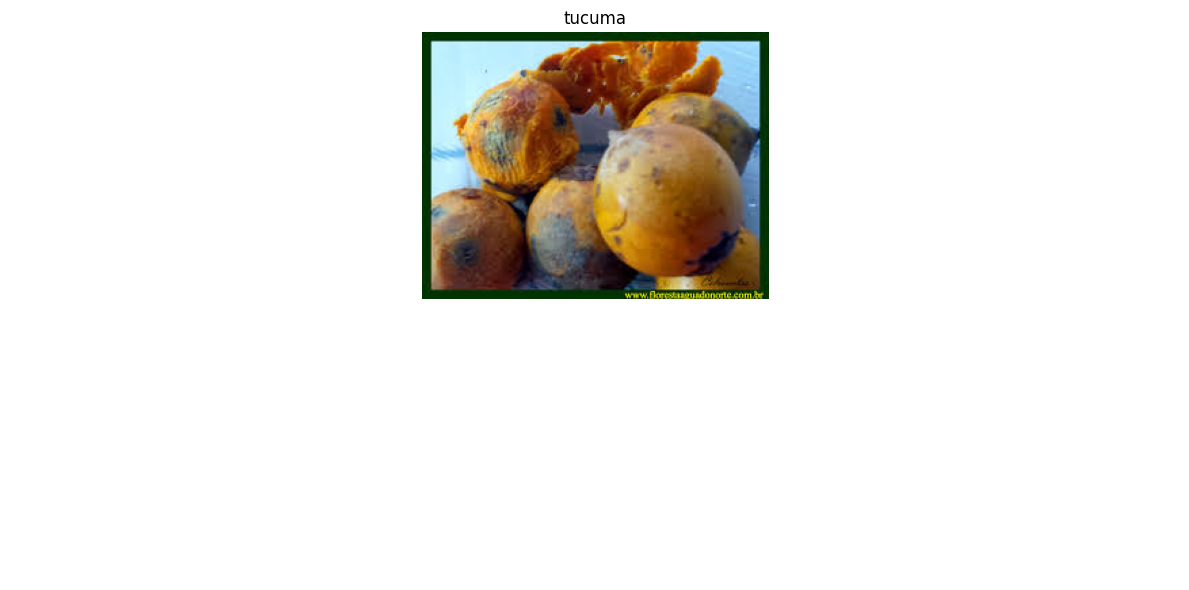

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

##Data Generation and Pre- processing:

In [6]:
import tensorflow as tf

image_size = (28, 28)
batch_size = 32
train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    )

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


##Understanding train ds and val ds:

In [7]:
for images, labels in train_ds.take(1): # Take one batch
 print("Images shape:", images.shape)
 print("Labels shape:", labels.shape)

Images shape: (32, 28, 28, 3)
Labels shape: (32,)


##Visualizing training dataset

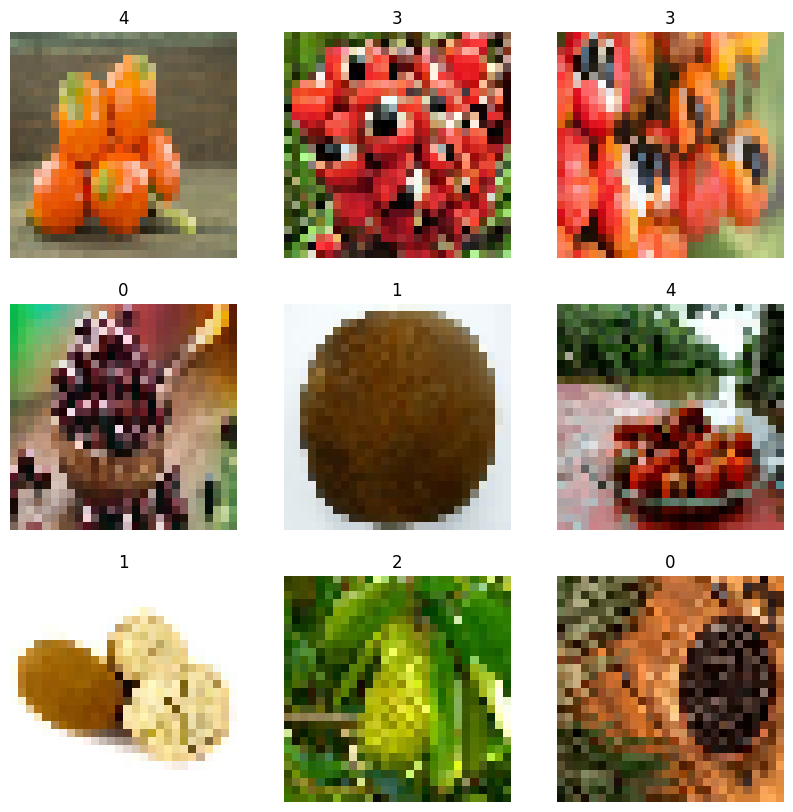

In [8]:
import numpy as np
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(np.array(images[i]).astype("uint8"))
    plt.title(int(labels[i]))
    plt.axis("off")

##Using Keras Image Data Generator (Old API):

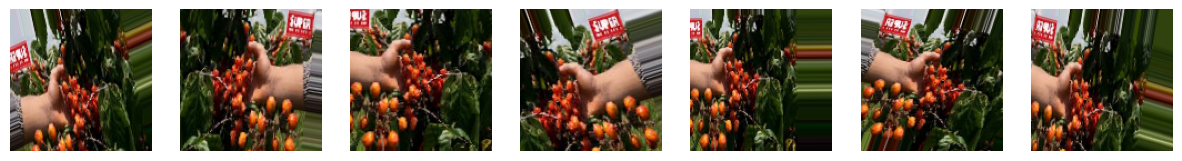

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=30,  # Rotate images by upto 30 degrees
    width_shift_range=0.2,  # Shift width by 20%
    height_shift_range=0.2,  # Shift height by 20%
    shear_range=0.2,  # Shear transformation
    zoom_range=0.2,  # Zoom in/out by 20%
    horizontal_flip=True,  # Flip images horizontally
    fill_mode='nearest'  # Fill in missing pixels
)

# Load an example image
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

img = image.load_img('/content/drive/MyDrive/AI and Machine Learning/Week5/FruitinAmazon/test/guarana/images (4).jpeg', target_size=(128, 128))
x = image.img_to_array(img)  # Convert to NumPy array
x = np.expand_dims(x, axis=0)

# Generate augmented images
aug_iter = datagen.flow(x, batch_size=1)

# Visualize 7 augmented images
fig, ax = plt.subplots(1, 7, figsize=(15, 5))

for i in range(7):
    batch = next(aug_iter)
    ax[i].imshow(batch[0].astype('uint8'))
    ax[i].axis('off')

plt.show()

##Using Keras tf.keras.layers.Random* (New API):

###Sample Implementation of tf.keras.layers.Random

In [10]:
from tensorflow import keras
from tensorflow.keras import layers
# This is a sample implementation, Thus I only use two augmentation, you can use more than two augmentation type for your project. Please check keras documentations for other available augmentation techniques.
data_augmentation_layers = [layers.RandomFlip("horizontal"),layers.RandomRotation(0.1),]
def data_augmentation(images):
 for layer in data_augmentation_layers:
  images = layer(images)
 return images

###Data Augemntation Layer directly in Model.

In [11]:
model = keras.Sequential([
layers.Input(shape=(128, 128, 3)),
*data_augmentation_layers, # Include augmentation before the model layers
layers.Conv2D(32, (3,3), activation="relu"),
layers.MaxPooling2D(),
layers.Flatten(),
layers.Dense(10, activation="softmax")
])

###Visualizing augemented Image.

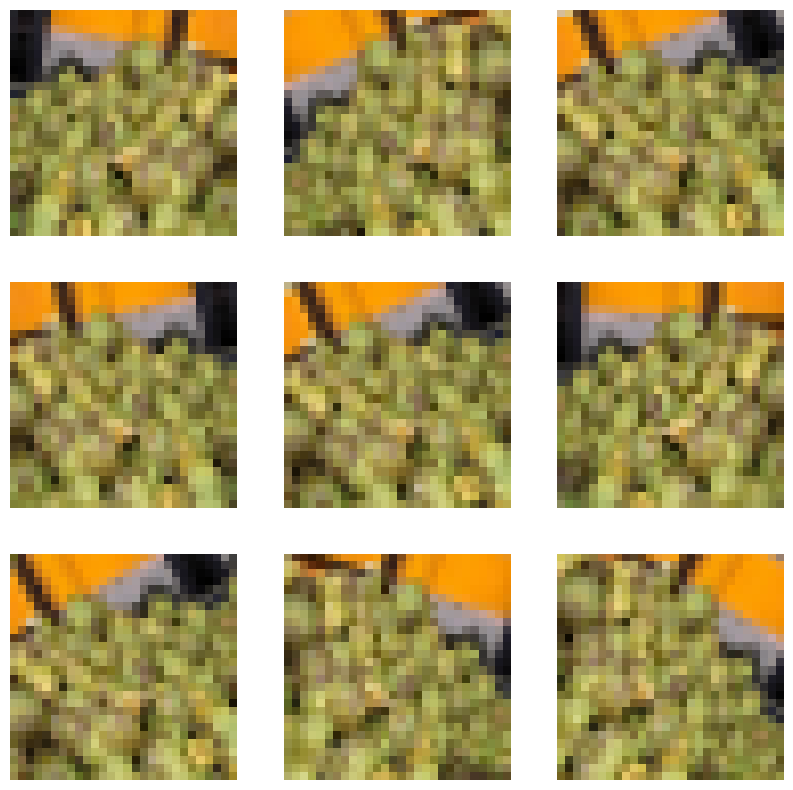

In [12]:
plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")

## Data Pre- processing: Scaling the data with Keras:

### Model Building:

In [13]:
import tensorflow as tf
import keras
from tensorflow.keras import layers
import numpy as np

# Define a simple CNN model
model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(image_size[0], image_size[1], 3)), # Add rescaling and use image_size
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")  # Use len(class_names) for output units
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the model using the tf.data.Dataset objects
# batch_size is already defined in the dataset creation
model.fit(train_ds, epochs=5, validation_data=val_ds)

# Evaluate the model
test_loss, test_acc = model.evaluate(val_ds)
print(f"Test accuracy: {test_acc:.4f}")

# Make predictions on a small sample from the validation dataset
for images_batch, labels_batch in val_ds.take(1):
    predictions = model.predict(images_batch[:5]) # Predict on first 5 images from the batch
    predicted_labels = np.argmax(predictions, axis=1)

    print("Predicted labels:", predicted_labels)
    print("Actual labels:", labels_batch[:5].numpy()) # Convert labels tensor to numpy for printing

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - accuracy: 0.1528 - loss: 1.8543 - val_accuracy: 0.0000e+00 - val_loss: 1.9101
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.3750 - loss: 1.7445 - val_accuracy: 0.0556 - val_loss: 1.8743
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4444 - loss: 1.6540 - val_accuracy: 0.2778 - val_loss: 1.7156
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5278 - loss: 1.5342 - val_accuracy: 0.2778 - val_loss: 1.7145
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.6250 - loss: 1.4517 - val_accuracy: 0.3889 - val_loss: 1.7163
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.3889 - loss: 1.7163
Test accuracy: 0.3889
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Predicted labels: [0 4 0 2 2]
Actual labels: [4 4 1 5 1]


#Batch Normalization Layer

In [14]:
from tensorflow.keras.layers import BatchNormalization
layer = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True,
beta_initializer="zeros", gamma_initializer="ones")

##Dropout Layer:

###Dropout Class in Keras:

In [15]:
from tensorflow.keras.layers import Dropout
layer = Dropout(0.5, noise_shape=None, seed=None)

###Following is the Sample with the Model Implemented with Batch Normalization and DropoutLayer.

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Flatten, Dense

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

# Define the model using the Sequential API with a list of layers
model = Sequential([
    # Data augmentation applied using Lambda layer
    layers.Lambda(data_augmentation, input_shape=(224, 224, 3)),

    # Rescaling layer to normalize pixel values
    layers.Rescaling(1. / 255),

    # First Convolutional Block
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Second Convolutional Block
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Third Convolutional Block
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Fourth Convolutional Block
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flatten the output of the last Conv2D layer
    Flatten(),

    # First Fully Connected Layer
    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Second Fully Connected Layer
    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Third Fully Connected Layer
    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Fourth Fully Connected Layer
    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Output Layer with 10 neurons (for classification task with 10 classes) Actually `len(class_names)`
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Use this for integer labels
    metrics=['accuracy']
)

# Summary of the model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 50176)          │             

 Total params: 26,257,930 (100.17 MB)

 Trainable params: 26,255,050 (100.16 MB)

 Non-trainable params: 2,880 (11.25 KB)

#Task 1

##Image classification via fine-tuning with VGG16

###Load the Pre- trained Model:

In [17]:
from tensorflow.keras.applications import VGG16
# Load the VGG16 model pre-trained on ImageNet, without the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


###Freeze the Layers:

In [19]:
# Freeze the layers of the base model
for layer in base_model.layers:
  layer.trainable = False

### Add a Custom Layers:

In [21]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
# Add custom layers on top of the pre-trained model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Reduces dimensions (height, width) to a single vector per image
x = Dense(1024, activation='relu')(x) # Fully connected layer with 1024 neurons
x = Dense(10, activation='softmax')(x) # Output layer for 10 classes (with softmax for multi-classclassification)

###Create the Final Model:

In [22]:
from tensorflow.keras.models import Model
# Create the final model
model = Model(inputs=base_model.input, outputs=x)

###Compile and Fit the model.

In [27]:
from tensorflow.keras.optimizers import Adam
# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit

<bound method TensorFlowTrainer.fit of <Functional name=functional_3, built=True>>

##UseDataAugmentationtoincreasethenumberoftrainingimage.•UsedeepermodelwithBNandDropOut layeraspresentedabove.         •UnderstandtheModelSummaryandTrainingBehavior.

In [36]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report

##Seting dataset path

In [37]:
train_dir = "/content/drive/MyDrive/AI and Machine Learning/Week5/FruitinAmazon/test"
test_dir = "/content/drive/MyDrive/AI and Machine Learning/Week5/FruitinAmazon/train"

##Visualizing one random image from each class


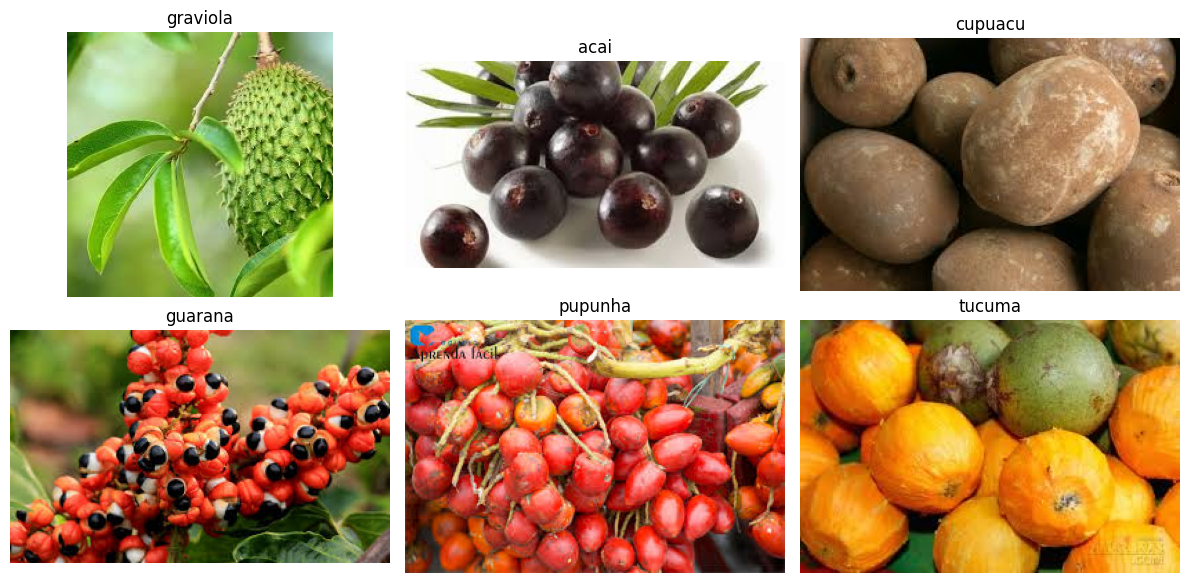

In [38]:
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls
    )
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)
    images.append(img)
    labels.append(cls)

plt.figure(figsize=(12, 6))
for i in range(len(images)):
    plt.subplot(2, (len(images)+1)//2, i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

##Checking for any corrupted images

In [39]:
corrupted = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


##Loading dataset

In [40]:
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2
seed = 123

##Training dataset

In [41]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=seed
)

Found 30 files belonging to 6 classes.
Using 24 files for training.


##Validation dataset

In [42]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=seed
)

Found 30 files belonging to 6 classes.
Using 6 files for validation.


##Testing dataset

In [43]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

Found 90 files belonging to 6 classes.


##Normalize dataset

In [44]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

if 'test_ds' in locals():
    test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

##Data augmentation

In [45]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

##Build improved deeper CNN with BN and Dropout

In [46]:
num_classes = len(classes)

model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    # Data augmentation
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
]
)

##Model Summary

In [47]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,620,102 (17.62 MB)

 Trainable params: 4,618,374 (17.62 MB)

 Non-trainable params: 1,728 (6.75 KB)

##Compile model

In [48]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

##Add callbacks

In [49]:
checkpoint = ModelCheckpoint(
    "best_improved_fruit_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

##Train model

In [50]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.3750 - loss: 2.5749

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 721ms/step - accuracy: 0.3750 - loss: 2.4602 - val_accuracy: 0.1667 - val_loss: 1.9238
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 466ms/step - accuracy: 0.4167 - loss: 1.8965 - val_accuracy: 0.1667 - val_loss: 1.8084
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 379ms/step - accuracy: 0.5417 - loss: 1.0879 - val_accuracy: 0.1667 - val_loss: 1.7066
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 390ms/step - accuracy: 0.6250 - loss: 1.0073 - val_accuracy: 0.1667 - val_loss: 1.6808
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 454ms/step - accuracy: 0.6667 - loss: 0.9179 - val_accuracy: 0.0000e+00 - val_loss: 1.7295
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 375ms/step - accuracy: 0.6250 - loss: 0.7491 - val_accuracy: 0.0000e+00 - val_loss: 1.7813
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 374ms/step - accuracy: 0.7083 - loss: 0.6959 - val_accuracy: 0.0000e+00 - val_loss: 1.7958
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 711ms/step - accuracy: 0.7917 - loss: 0.6069 - val_accuracy: 0.0000e+00 - val_

##Plot training behaviour

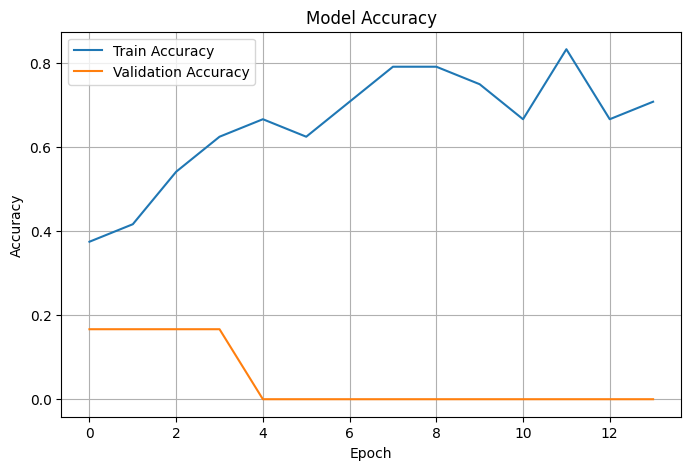

In [51]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.grid(True)
plt.show()

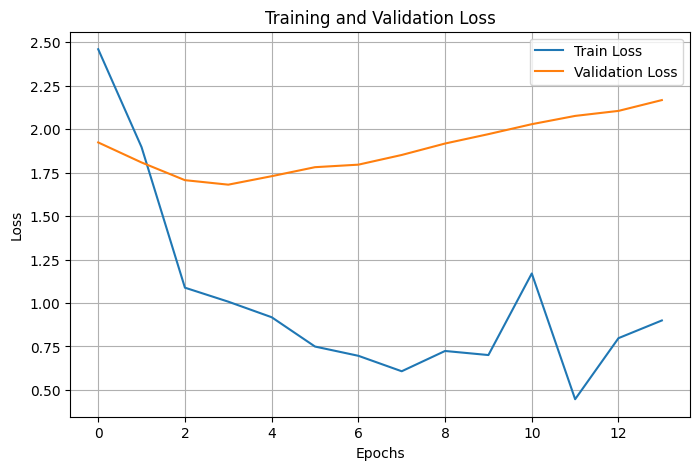

In [52]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

#Task- 2:

##Transfer Learning Implementation (Using ImageNet Weights)

In [57]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report

In [53]:
train_dir = "/content/drive/MyDrive/AI and Machine Learning/Week5/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI and Machine Learning/Week5/FruitinAmazon/test"

img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2
seed = 123

In [59]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=seed
)

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [60]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=seed
)

Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [61]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [62]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [64]:
base_model = MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


##Model Evaluation

In [65]:
# Evaluate
loss, accuracy = model.evaluate(val_ds)
print("Validation Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.1667 - loss: 1.8213 
Validation Accuracy: 0.1666666716337204


In [68]:
base_model.trainable = False

In [69]:
model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    data_augmentation,
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

In [70]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [71]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [72]:
checkpoint = ModelCheckpoint(
    "transfer_learning_fruit_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

In [73]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 604ms/step - accuracy: 0.1389 - loss: 2.3151 - val_accuracy: 0.8333 - val_loss: 1.5347
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step - accuracy: 0.1389 - loss: 1.9604 - val_accuracy: 0.0000e+00 - val_loss: 1.7694
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step - accuracy: 0.2361 - loss: 2.1158 - val_accuracy: 0.0000e+00 - val_loss: 1.6879
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - accuracy: 0.2222 - loss: 1.8913 - val_accuracy: 0.0000e+00 - val_loss: 1.9057
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.1806 - loss: 1.9143 - val_accuracy: 0.0000e+00 - val_loss: 1.9665
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.2639 - loss: 1.9289 - val_accuracy: 0.0000e+00 - val_loss: 1.9393
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step - accuracy: 0.1667 - loss: 2.0771 - val_accuracy: 0.0000e+00 - val_loss: 1.9630
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - accuracy: 0.1667 - loss: 1.9866 - val_accu

##Inference Output (Predictions)

In [74]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# Convert class names
# Use the global class_names variable, which was correctly extracted earlier
# class_names = train_ds.class_names # This line caused the error

# Show few predictions
for i in range(10):
    print("Actual:", class_names[y_true[i]],
          "| Predicted:", class_names[y_pred[i]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
Actual: pupunha | Predicted: tucuma
Actual: pupunha | Predicted: tucuma
Actual: pupunha | Predicted: tucuma
Actual: tucuma | Predicted: tucuma
Actual: tucuma | Predicted: tucuma
Actual: tucuma | Predicted: tucuma
Actual: tucuma | Predicted: tucuma
Actual: tucuma | Predicted: tucuma
Actual: tucuma | Predicted: tucuma
Actual: tucuma | Predicted: tucuma


##Classification Report

In [76]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    labels=range(num_classes)
)

print(report)

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         0
     cupuacu       0.00      0.00      0.00         0
    graviola       0.00      0.00      0.00         0
     guarana       0.00      0.00      0.00         0
     pupunha       0.00      0.00      0.00         3
      tucuma       0.83      1.00      0.91        15

    accuracy                           0.83        18
   macro avg       0.14      0.17      0.15        18
weighted avg       0.69      0.83      0.76        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me